In [1]:
import pandas as pd 
import numpy as np 
import scipy
from matplotlib.colors import ListedColormap
import scikit_posthocs
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib
sns.set(font_scale=1.4)
matplotlib.rcParams['pdf.fonttype'] = 42

In [4]:
s34fcsc_contrast_table = pd.read_csv('/Users/selammehreteab/Desktop/Brooks_Lab_folder/u2af1_illumina_filtered_s34f_csc_vs_u2af1_illumina_wt_dmso.csv')
s34fdmso_contrast_table = pd.read_csv('/Users/selammehreteab/Desktop/Brooks_Lab_folder/u2af1_illumina_filtered_s34f_dmso_vs_u2af1_illumina_wt_dmso.csv')
wtcsc_contrast_table = pd.read_csv('/Users/selammehreteab/Desktop/Brooks_Lab_folder/u2af1_illumina_filtered_u2af1_illumina_wt_csc_vs_u2af1_illumina_wt_dmso.csv')
contrast_tables_list = [s34fcsc_contrast_table,s34fdmso_contrast_table,wtcsc_contrast_table]

for i in contrast_tables_list:
    i = i.rename(columns = {'Unnamed: 0':'#Gene'}, inplace = True)

s34fcsc_contrast = s34fcsc_contrast_table.drop(columns=['baseMean','lfcSE', 'stat', 'pvalue','padj'], axis = 1)
s34fdmso_contrast = s34fdmso_contrast_table.drop(columns=['baseMean','lfcSE', 'stat', 'pvalue','padj'], axis = 1)
wtcsc_contrast = wtcsc_contrast_table.drop(columns=['baseMean','lfcSE', 'stat', 'pvalue','padj'], axis = 1)

# to export as RNK file
s34fcsc_contrast.to_csv('s34fcsc_log2fc.RNK', sep = '\t', index = False)
s34fdmso_contrast.to_csv('s34fdmso_log2fc.RNK', sep='\t', index = False)
wtcsc_contrast.to_csv('wtcsc_log2fc.RNK', sep='\t', index= False)
wtcsc_contrast

,#Gene,log2FoldChange
0,A4GALT,0.199674
1,AAAS,-0.077170
2,AACS,0.312840
3,AACSP1,-1.156798
4,AADAT,-0.243106
...,...,...
8212,ZUP1,0.008418
8213,ZWILCH,-0.359037
8214,ZWINT,-0.609676
8215,ZXDB,-0.714665


/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_10806/71968380.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df = df.rename(columns = {'NAME':'Gene Set'}, inplace =True)
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_10806/71968380.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_s34fdmso['Comparison'] = 'U2AF1 S34F DMSO'
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_10806/71968380.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

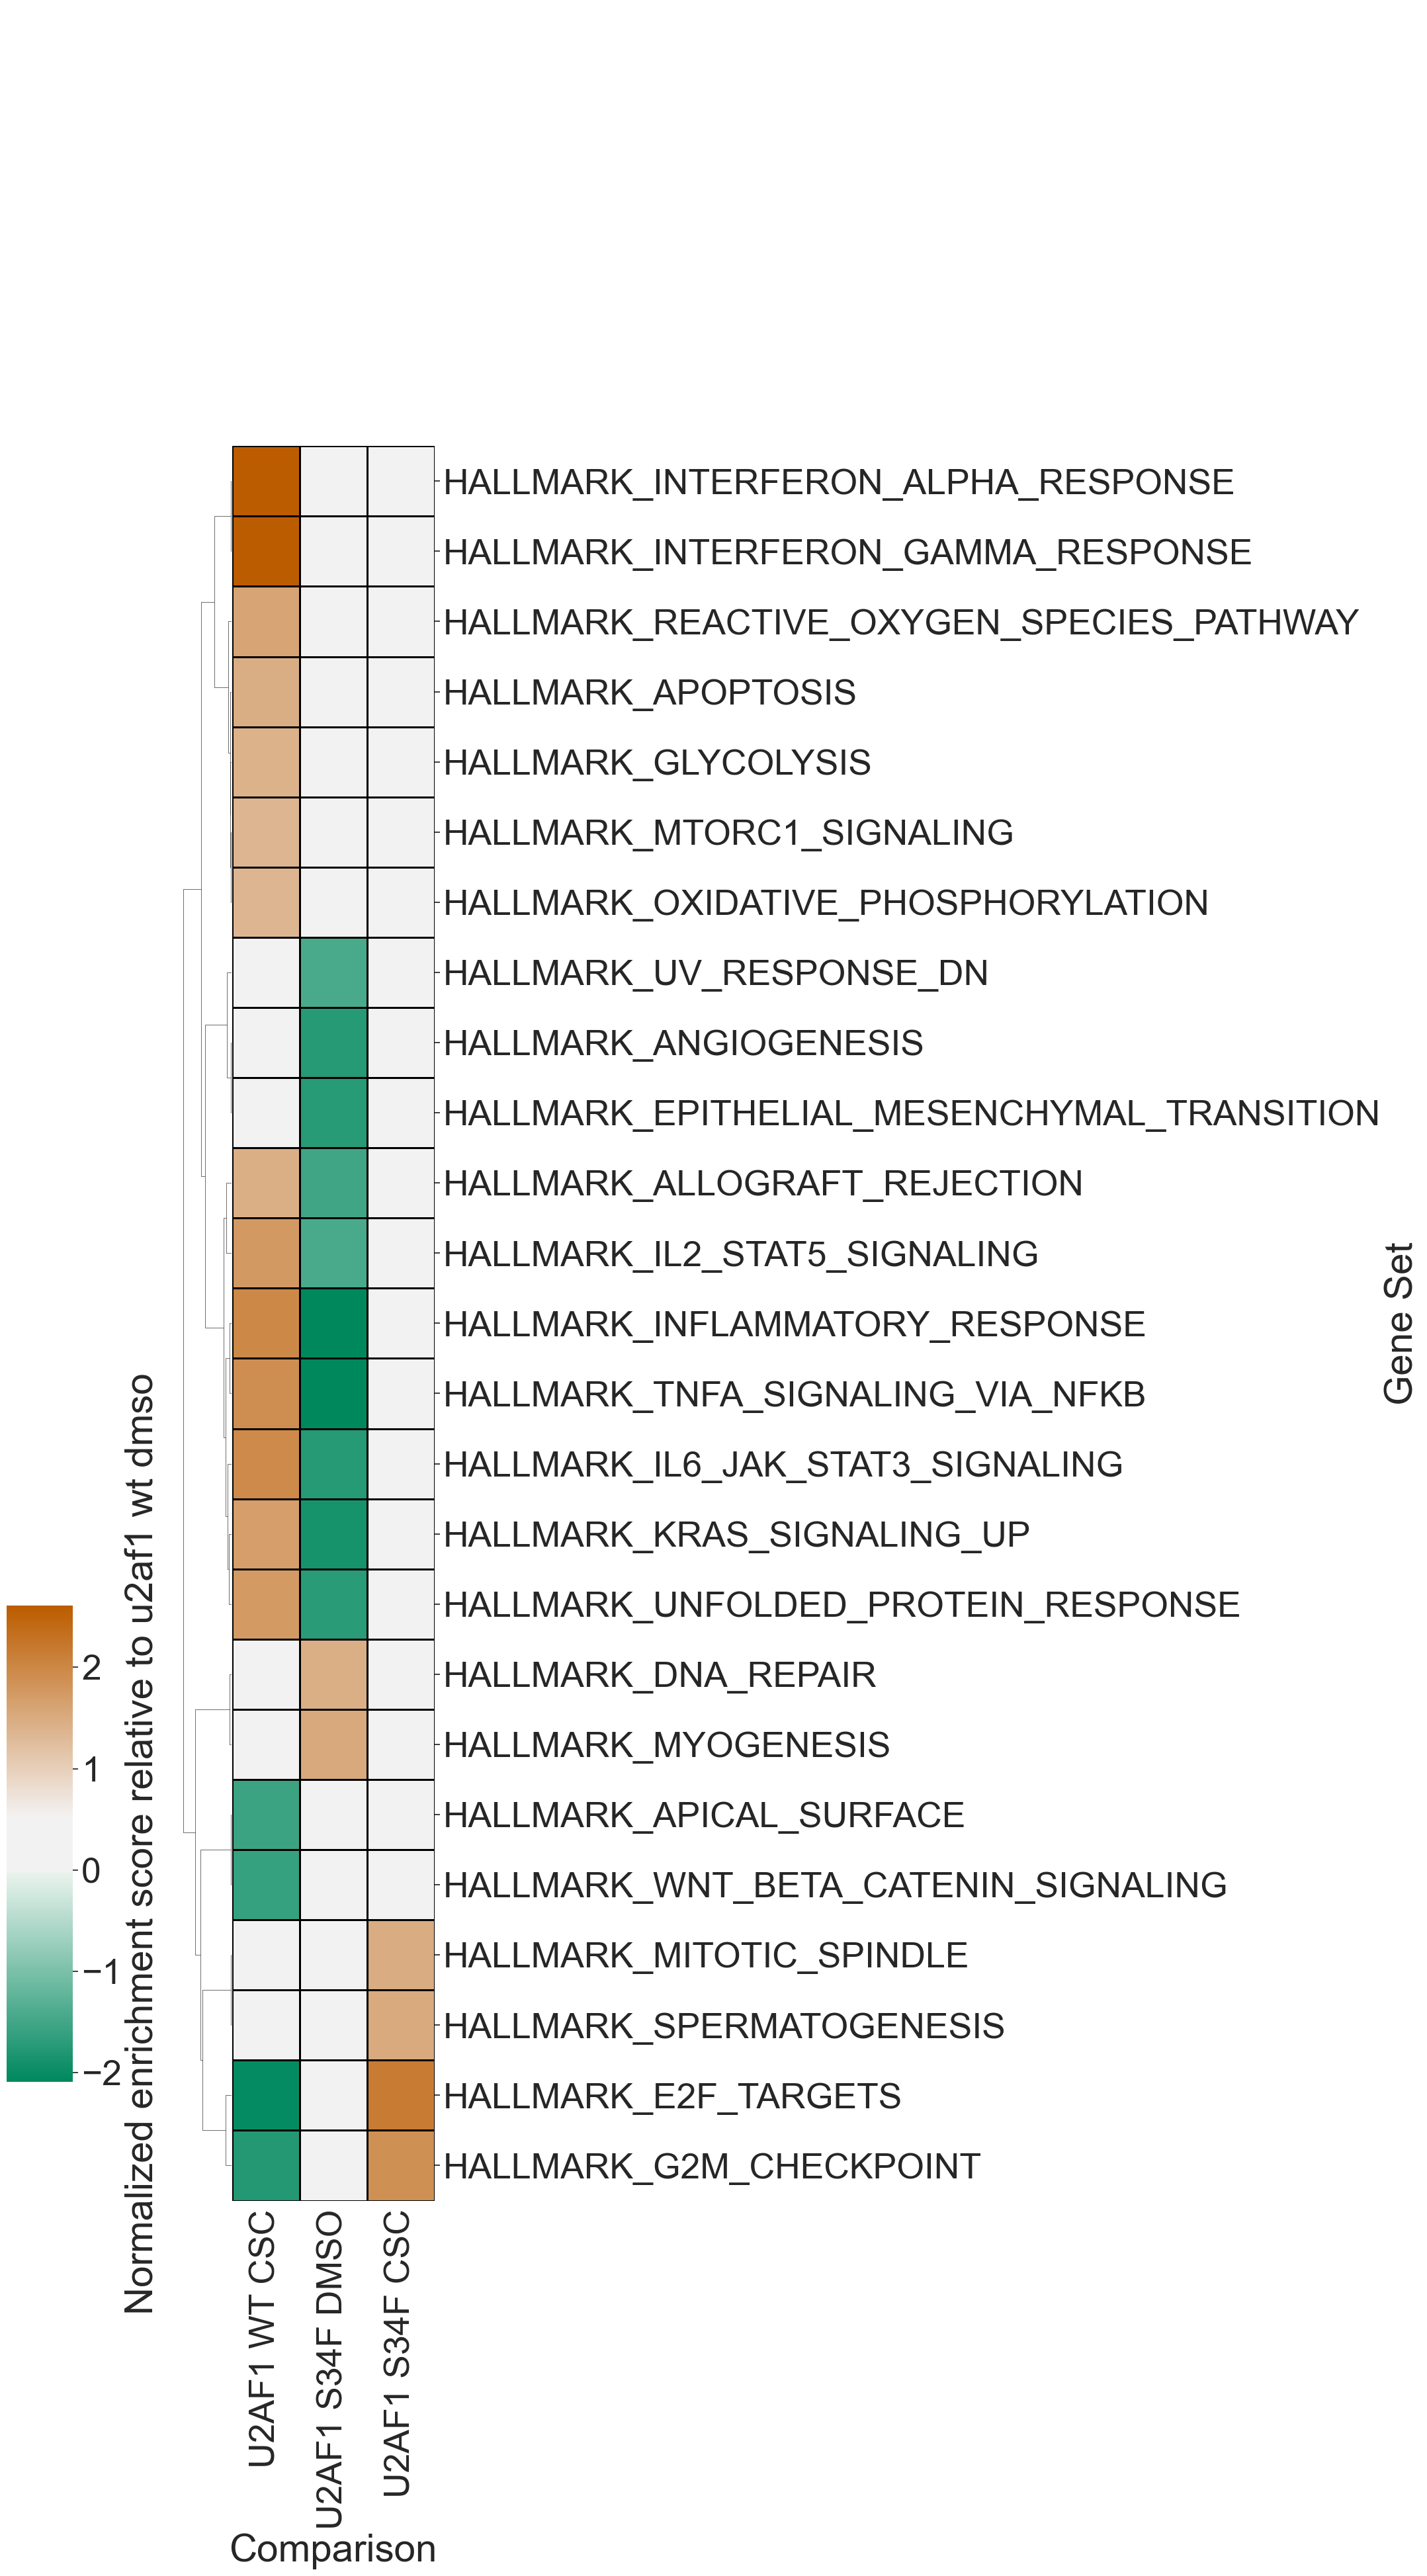

In [12]:
# plot heatmap
sns.set(font_scale=3.5)

s34fdmso_pos = pd.read_csv('/Users/selammehreteab/gsea_home/output/jun03/my_analysis.GseaPreranked.1717450944546/gsea_report_for_na_pos_1717450944546.tsv', sep='\t')
s34fcsc_pos = pd.read_csv('/Users/selammehreteab/gsea_home/output/jun03/my_analysis.GseaPreranked.1717450964478/gsea_report_for_na_pos_1717450964478.tsv', sep='\t')
wtcsc_pos = pd.read_csv('/Users/selammehreteab/gsea_home/output/jun03/my_analysis.GseaPreranked.1717450976522/gsea_report_for_na_pos_1717450976522.tsv', sep='\t')

s34fdmso_neg = pd.read_csv('/Users/selammehreteab/gsea_home/output/jun03/my_analysis.GseaPreranked.1717450944546/gsea_report_for_na_neg_1717450944546.tsv', sep='\t')
s34fcsc_neg =  pd.read_csv('/Users/selammehreteab/gsea_home/output/jun03/my_analysis.GseaPreranked.1717450964478/gsea_report_for_na_neg_1717450964478.tsv', sep='\t')
wtcsc_neg = pd.read_csv('/Users/selammehreteab/gsea_home/output/jun03/my_analysis.GseaPreranked.1717450976522/gsea_report_for_na_neg_1717450976522.tsv', sep='\t')

s34fdmso = pd.concat([s34fdmso_pos,s34fdmso_neg], ignore_index = True)
wtcsc = pd.concat([wtcsc_pos, wtcsc_neg], ignore_index = True)
s34fcsc = pd.concat([s34fcsc_pos,s34fcsc_neg], ignore_index = True)

dfs = [s34fdmso, wtcsc,s34fcsc]
for df in dfs:
    df = df.drop(['GS<br> follow link to MSigDB','GS DETAILS','SIZE','ES','FWER p-val', 'RANK AT MAX',
                 'LEADING EDGE', 'Unnamed: 11'], axis=1, inplace=False)
#filter for pval

filter_s34fdmso = s34fdmso.loc[(s34fdmso['NOM p-val'] < 0.05) & (s34fdmso['FDR q-val'] < 0.25)]
filter_wtcsc = wtcsc.loc[(wtcsc['NOM p-val'] < 0.05) & (wtcsc['FDR q-val'] < 0.25)]
filter_s34fcsc = s34fcsc.loc[(s34fcsc['NOM p-val'] < 0.05) & (s34fcsc['FDR q-val'] < 0.25)]

dflist = [filter_s34fdmso,filter_wtcsc,filter_s34fcsc]
for df in dflist:
    df = df.rename(columns = {'NAME':'Gene Set'}, inplace =True)
    filter_s34fdmso['Comparison'] = 'U2AF1 S34F DMSO'
    filter_wtcsc['Comparison'] = 'U2AF1 WT CSC'
    filter_s34fcsc['Comparison'] = 'U2AF1 S34F CSC'
    
    
s34fdmso_wtcsc = pd.concat([filter_s34fdmso,filter_wtcsc], ignore_index = True)
s34fdmso_wtcsc_s34fcsc = pd.concat([filter_s34fcsc, s34fdmso_wtcsc], ignore_index = True)
s34fdmso_wtcsc_s34fcsc

heatmap_s34fwtdmsocsc = pd.pivot_table(s34fdmso_wtcsc_s34fcsc, values = 'NES', index = 'Gene Set', columns = 'Comparison')

reordering_column = ['U2AF1 WT CSC', 'U2AF1 S34F DMSO','U2AF1 S34F CSC']
heatmap_s34fwtdmsocsc =heatmap_s34fwtdmsocsc.reindex(reordering_column, axis=1)

heatmap_s34fwtdmsocsc = heatmap_s34fwtdmsocsc.fillna(0)

heatmap = sns.clustermap(heatmap_s34fwtdmsocsc, figsize = (20, 40), xticklabels=True, yticklabels=True, col_cluster=False, linecolor='black', 
               linewidths = 1, cmap=sns.diverging_palette(150, 30, s=100, sep=30, n=9, as_cmap=True),
                    cbar_kws = {'label':'Normalized enrichment score relative to u2af1 wt dmso'},
                         cbar_pos=(-.1, .2, 0.05, 0.18))

# heatmap.savefig("Downloads/geneexp_hallmark_heatmap.pdf", format='pdf', transparent=True)

# stress granule heatmap

In [ ]:
sgproteindf = pd.read_csv(

In [ ]:
sns.set(font_scale=3.5)


df_list = [s34fcsc_contrast, s34fdmso_contrast, wtcsc_contrast]